In [ ]:
!pip install bertopic==0.16.0 datasets==2.16.1 Arabic-Stopwords==0.4.3

In [ ]:
from datasets import load_dataset
import pandas as pd
import re
import random
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime


def clean_text(text: str):
    if not isinstance(text,str):
      return ""

    #remove_urls
    text = re.sub(r'http\S+', 'رابط', text)

    #remove any digit with رقم
    text = re.sub(r'\d+', 'رقم', text)

    #set space before any ponctuation
    text = re.sub(r'([^\w\s])', r' \1 ', text)

    #remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    words = word_tokenize(text)
    text = " ".join([w for w in words if len(w)>1])

    return text.lower().strip()


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
ar_datasets=load_dataset("inparallel/saudinewsnet")

In [ ]:
ar_datasets['train'][0]

{'source': 'aawsat',
 'url': 'http://aawsat.com/home/article/410826/بريطانيا-أربعة-محاور-لاستراتيجية-جديدة-تتصدى-للتطرف-على-مدى-خمس-سنوات',
 'date_extracted': '2015-07-21 02:51:32',
 'title': 'بريطانيا: أربعة محاور لاستراتيجية جديدة تتصدى للتطرف على مدى خمس سنوات',
 'author': 'لندن: رنيم حنوش',
 'content': 'حدد رئيس الوزراء البريطاني ديفيد كاميرون، اليوم (الاثنين)، ملامح استراتيجية للتصدي للتطرف داخل بريطانيا؛ وهي مسألة اعتبرها كاميرون "صراع جيلنا"، متعهدا خلال خطابه في مدينة بيرمنغهام بالتصدي لهؤلاء الذين ينشرون التطرف بين الشبان المسلمين البريطانيين.\n\n ورسم كاميرون الاطار العام لاستراتيجية مكافحة التطرف التي المقرر ان تنشر كاملة في وقت لاحق هذا العام، والتي تسعى للتصدي لانتشار الأفكار المتطرفة التي يروج لها متشددو تنظيم "داعش".\n\n وحسبما تناقلت وسائل الإعلام البريطانية، فإن خطة رئيس الوزراء ستكون على مدى خمسة أعوام للقضاء على التطرف الداخلي من خلال أربعة محاور، وهي: القضاء على إيديولوجية التطرف، والوقوف في وجه عمليات التجنيد وغسل الأدمغة بالأفكار المتطرفة، وإعادة اصوات الاسلام الم

In [ ]:
raw_dataset=[
    {
        "text" : rec["content"],
        "source" : rec["source"],
        "date" : rec["date_extracted"]
    }
    for rec in ar_datasets['train']
]

In [ ]:
raw_dataset_df = pd.DataFrame(raw_dataset)
raw_dataset_df = raw_dataset_df.sample(frac=1 , random_state=101)

In [ ]:
raw_dataset_df.head()

,text,source,date
26442,عين اليوم – الدمام\n عقدت أمانة المنطقة الشرق...,3alyoum,2015-08-09 20:45:39
24574,"""لم نر الإرهاب إلا بعد تسييس الدين، ليصير الو...",alwatan,2015-08-07 06:32:39
20441,رغد عشميل – عين اليوم\n عزز فريق ريال مدريد ا...,3alyoum,2015-08-06 19:16:04
7927,أوضحت إدارة مستشفى الدوادمي العام في بيان ...,alriyadh,2015-07-24 16:23:27
14012,الشعر الجميل يبقى محفوراً في الذاكرة لا يم...,alriyadh,2015-07-31 03:53:17


In [ ]:
raw_dataset_df['text'] = raw_dataset_df['text'].apply(clean_text)

In [ ]:
raw_dataset_df['text_len'] = raw_dataset_df['text'].apply(len)

In [ ]:
raw_dataset_df.head(2)

,text,source,date,text_len
26442,عين اليوم الدمام عقدت أمانة المنطقة الشرقية ال...,3alyoum,2015-08-09 20:45:39,1094
24574,`` لم نر الإرهاب إلا بعد تسييس الدين ليصير الو...,alwatan,2015-08-07 06:32:39,3375


<Axes: xlabel='text_len', ylabel='Count'>

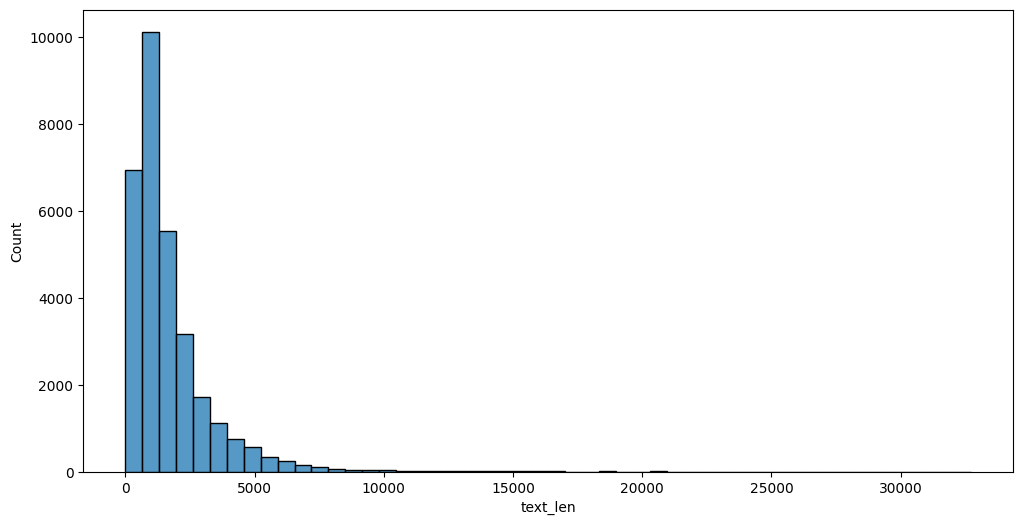

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(raw_dataset_df['text_len'], bins=50)

In [ ]:
print(raw_dataset_df.shape)
raw_dataset_df = raw_dataset_df[raw_dataset_df['text_len'] <= 10000]
print(raw_dataset_df.shape)

(31030, 4)
(30902, 4)


In [ ]:
print(raw_dataset_df.shape)
raw_dataset_df.drop_duplicates('text', inplace=True)
print(raw_dataset_df.shape)

(30902, 4)
(29696, 4)


In [ ]:
raw_dataset_df['datetime_stamp'] = raw_dataset_df["date"].apply(lambda x: datetime.strptime(x, '%Y-%m-%d %H:%M:%S'))

raw_dataset_df['datetime_stamp'] = raw_dataset_df['datetime_stamp'].apply(lambda x: x.replace(hour=0, minute=0 ,second=0 ))

##Embedding

In [ ]:
from sentence_transformers import SentenceTransformer

model_id = "sentence-transformers/LaBSE"
embedding_model = SentenceTransformer(model_id, device = "cuda:0")

In [ ]:
news_embedding =embedding_model.encode(raw_dataset_df['text'].values, show_progress_bar=True)

Batches:   0%|          | 0/928 [00:00<?, ?it/s]

In [ ]:
news_embedding.shape

(29696, 768)

## Réduction de dimension avec UMAP



In [ ]:
from umap import UMAP

umap_model=UMAP(n_neighbors=15,min_dist=0.0,n_components=15,random_state=101,metric="cosine")

##Clustering

In [ ]:
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(min_cluster_size=50,
                        metric = 'euclidean',
                        cluster_selection_method='eom',
                        prediction_data=True)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


##Vectoriser

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import arabicstopwords.arabicstopwords as stp

stop_words = stp.stopwords_list()

verctoriser_model = CountVectorizer(min_df=3,
                                    stop_words=stop_words,
                                    analyzer='word',
                                    max_df=0.5,
                                    ngram_range=(1, 3)
                                    )

##Topic Representer

In [ ]:
from bertopic.representation import KeyBERTInspired

keybert_model = KeyBERTInspired()

representation_model = {
    "keyBert" : keybert_model
}

## Commençons



In [ ]:
from bertopic import BERTopic

topic_model = BERTopic(
    #Pipeline models

    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=verctoriser_model,
    representation_model=representation_model,

    #les hyperparamètres
    top_n_words=10,
    verbose=True
)

topics, probs = topic_model.fit_transform(
    raw_dataset_df['text'].values,
    news_embedding
)

2026-02-03 01:25:17,974 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-03 01:26:02,252 - BERTopic - Dimensionality - Completed ✓
2026-02-03 01:26:02,255 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-03 01:26:10,086 - BERTopic - Cluster - Completed ✓
2026-02-03 01:26:10,095 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-02-03 01:27:18,744 - BERTopic - Representation - Completed ✓


In [ ]:
raw_dataset_df['text'].values[133]

'استنكر عدد من المسؤولين في منطقة المدينة المنورة حادث التفجير الإجرامي الذي استهدف المصلين في مسجد قوات طوارئ منطقة عسير وراح ضحيته عدد من رجال الأمن وإصابة آخرين مؤكدين أن الحادثة الغادرة كشفت زيف وبطلان اد عاءات المنظمات الإرهابية الذين يرددون شعارات بر اقة تستعطف شباب الأمة وتغر بهم وتغويهم ونو مدير فرع وزارة الثقافة والإعلام بالمنطقة الدكتور صلاح بن سليمان الردادي بتماسك الشعب السعودي وقيادته الذي بات مضرب مثل مع كل الأحداث والملمات التي تهدف إلى زعزعة الأمن وتهديد استقرار البلاد سائلا الله تعالى أن يتقبل الشهداء بالرحمة والمغفرة وأن يمن على المصابين بالشفاء العاجل وأن يحفظ أمن هذا البلد واستقراره ووحدته الوطنية وقيادته الرشيدة وعب الردادي عن عزائه ومواساته للقيادة الرشيدة وأهالي وذوي الشهداء راجيا من الله عز وجل أن يربط على قلوب ذويهم ويرزقهم الصبر والسلوان وأن يمن على المصابين بالشفاء العاجل وأن يديم على بلادنا أمنها واستقرارها وأن يرد كيد الكائدين في نحورهم من جانبه رفع رئيس مجلس إدارة جمعية البر والخدمات الاجتماعية الدكتور حمدان بن عبدالعزيز الحربي باسمه ونيابة عن منسوبي مجلس 

In [ ]:
topics[133] , probs[133]

(3, np.float64(1.0))

In [ ]:
topic_model.get_topic(3)

[('الإرهاب', np.float64(0.011800259597838893)),
 ('الإرهابي', np.float64(0.010770087853726972)),
 ('الإرهابية', np.float64(0.010458337611141625)),
 ('الإسلام', np.float64(0.009664116792278486)),
 ('داعش', np.float64(0.00891226471475426)),
 ('الفكر', np.float64(0.008624103786648633)),
 ('رجال الأمن', np.float64(0.008529513851887386)),
 ('قوات الطوارئ', np.float64(0.008334300397853253)),
 ('مسجد', np.float64(0.008242112837567653)),
 ('المسلمين', np.float64(0.008032791258724073))]

In [ ]:
raw_dataset_df['topic'] = topics
raw_dataset_df['prob'] = probs

In [ ]:
raw_dataset_df.head()

,text,source,date,text_len,datetime_stamp,topic,prob
26442,عين اليوم الدمام عقدت أمانة المنطقة الشرقية ال...,3alyoum,2015-08-09 20:45:39,1094,2015-08-09 20:45:39,-1,0.000000
24574,`` لم نر الإرهاب إلا بعد تسييس الدين ليصير الو...,alwatan,2015-08-07 06:32:39,3375,2015-08-07 06:32:39,-1,0.000000
20441,رغد عشميل عين اليوم عزز فريق ريال مدريد الإسبا...,3alyoum,2015-08-06 19:16:04,1874,2015-08-06 19:16:04,0,1.000000
7927,أوضحت إدارة مستشفى الدوادمي العام في بيان لها ...,alriyadh,2015-07-24 16:23:27,429,2015-07-24 16:23:27,19,0.891614
14012,الشعر الجميل يبقى محفورا في الذاكرة لا يمحي من...,alriyadh,2015-07-31 03:53:17,1049,2015-07-31 03:53:17,1,1.000000


In [ ]:
raw_dataset_df[raw_dataset_df['topic'] == 3]

,text,source,date,text_len,datetime_stamp,topic,prob
11125,نزعات التعصب والتطرف والتوحش التي اشتدت وتعاظم...,alyaum,2015-07-26 16:52:23,3604,2015-07-26 16:52:23,3,0.906028
10418,لا ندري هل نفرح ونحتفل بإنجازات صقور الوطن في ...,aljazirah,2015-07-26 16:49:52,3451,2015-07-26 16:49:52,3,1.000000
28168,استنكر عدد من المسؤولين في منطقة المدينة المنو...,aljazirah,2015-08-10 19:02:57,2869,2015-08-10 19:02:57,3,1.000000
24819,استنكر أهالي المناطق الجنوبية يوم أمس الحادث ا...,alyaum,2015-08-07 06:27:54,900,2015-08-07 06:27:54,3,1.000000
14250,فعلا يحتار الكاتب أي كاتب عندما يهم في كتابة م...,alwatan,2015-07-31 04:07:59,5196,2015-07-31 04:07:59,3,1.000000
...,...,...,...,...,...,...,...
30174,أدان مجلس الوزراء بمملكة البحرين وبشدة التفجير...,alriyadh,2015-08-11 14:19:54,1096,2015-08-11 14:19:54,3,1.000000
9213,أدانت منظمة التعاون الإسلامي والولايات المتحدة...,alriyadh,2015-07-25 09:44:56,738,2015-07-25 09:44:56,3,1.000000
6663,خضر الخيرات عين اليوم كر مدير التعليم بمحافظة ...,3alyoum,2015-07-24 15:57:03,732,2015-07-24 15:57:03,3,1.000000
3356,تأتي هذه الجريمة قتل العقيد راشد الصفيان رحمه ...,aljazirah,2015-07-22 10:02:04,7465,2015-07-22 10:02:04,3,1.000000


In [ ]:
raw_dataset_df[raw_dataset_df['topic'] == 17]

,text,source,date,text_len,datetime_stamp,topic,prob
16259,واس المنامة دانت مملكة البحرين أمس بشدة العمل ...,sabq,2015-08-01 07:51:31,701,2015-08-01 07:51:31,17,1.000000
28697,بعد مرور رقم سنوات على تشييد جدار الفصل العنصر...,alwatan,2015-08-10 19:41:59,1860,2015-08-10 19:41:59,17,0.837424
10659,طالبت وزارة الخارجية الفلسطينية اليوم الأحد بت...,alriyadh,2015-07-26 17:21:56,1225,2015-07-26 17:21:56,17,0.832463
20658,عاشت حفصة الدوابشة مثل آخرين ليلة رعب حقيقية ت...,aawsat,2015-08-06 02:37:02,1329,2015-08-06 02:37:02,17,0.578316
20654,بعد تكرار عمليات القتل حرق اشتعلت إسرائيل بجدل...,aawsat,2015-08-06 02:36:57,2935,2015-08-06 02:36:57,17,0.657132
...,...,...,...,...,...,...,...
23444,رويترز تل أبيب احتجزت `` إسرائيل `` يوم الثلاث...,sabq,2015-08-06 01:51:43,1608,2015-08-06 01:51:43,17,0.527722
13026,عين اليوم رام الله اعلن الرئيس الفلسطيني محمود...,3alyoum,2015-07-31 15:03:29,410,2015-07-31 15:03:29,17,0.977304
30387,إنقض عدد من أفراد الشرطة الإسرائيلية على أحد ح...,alwatan,2015-08-11 18:45:22,1254,2015-08-11 18:45:22,17,0.743139
11506,تحولت باحات المسجد الأقصى في مدينة القدس إلى س...,aawsat,2015-07-27 17:10:19,794,2015-07-27 17:10:19,17,0.708597


In [ ]:
 topic_model.get_topic_info()

,Topic,Count,Name,Representation,keyBert,Representative_Docs
0,-1,9081,-1_مليار_رقم مليار_بنسبة رقم رقم_رقم رقم المائة,"[مليار, رقم مليار, بنسبة رقم رقم, رقم رقم الما...","[الملك سلمان عبدالعزيز, عبدالعزيز آل سعود, سلم...",[تحت رعاية خادم الحرمين الشريفين الملك سلمان ب...
1,0,4092,0_القدم_النادي_الموسم_اللاعب,"[القدم, النادي, الموسم, اللاعب, اللاعبين, لكرة...","[تشيلسي, اللاعبين, لاعبين, لاعبي, الموسم الماض...",[وصلت بعثة فريق الهلال الكروي الأول إلى العاصم...
2,1,1014,1_التحرش_الكتاب_الشاعر_الشعر,"[التحرش, الكتاب, الشاعر, الشعر, الرواية, الكتا...","[القارئ, الأدبي, الأدبية, شاعر, الأدب, الشاعر,...",[المحبة عن بعد تخييل ليس إلا تحتاج إلى مجنون و...
3,2,950,2_عدن_المقاومة_الحوثيين_الحوثي,"[عدن, المقاومة, الحوثيين, الحوثي, اليمن, الشعب...","[مطار عدن, عدن, الحوثيين وقوات, محافظة عدن, ها...",[وصلت أمس الأحد تجهيزات عسكرية مقدمة من دول ال...
4,3,810,3_الإرهاب_الإرهابي_الإرهابية_الإسلام,"[الإرهاب, الإرهابي, الإرهابية, الإسلام, داعش, ...","[استهدف مسجد, مسجد قوات الطوارئ, داعش, الجماعا...",[أدانت عدد من دول العالم التفجير الإرهابي الذي...
...,...,...,...,...,...,...
85,84,53,84_المطعم_مطعم_الطعام_الفندق,"[المطعم, مطعم, الطعام, الفندق, الأطباق, المطبخ...","[سلسلة مطاعم, المطعم, المطاعم, مطعم, مطاعم, ال...",[المطاعم المتخصصة بمطبخ واحد غالبا ما تكون أفض...
86,85,53,85_موبايلي_خدمات الاتصالات_التجمعات_العملاء,"[موبايلي, خدمات الاتصالات, التجمعات, العملاء, ...","[خدمات الاتصالات, شركة الاتصالات السعودية, الخ...",[عبدالسلام العنزي سبق الرياض أنجزت هيئة الاتصا...
87,86,52,86_السوريين_الأشقاء_الوطنية السعودية_السعودية ...,"[السوريين, الأشقاء, الوطنية السعودية, السعودية...","[للأشقاء اللاجئين السوريين, اللاجئين السوريين,...",[أنهت الحملة الوطنية السعودية المرحلة الثالثة ...
88,87,52,87_العسل_النحل_الباحة_المهرجان,"[العسل, النحل, الباحة, المهرجان, مهرجان العسل,...","[لمهرجان العسل الدولي, مهرجان العسل الدولي, فع...",[أحمد البشيري الباحة بلغت مبيعات مهرجان العسل ...


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,keyBert,Representative_Docs
0,-1,8711,-1_سلمان عبدالعزيز_أمير منطقة_المعرض_القرآن,"[سلمان عبدالعزيز, أمير منطقة, المعرض, القرآن, ...","[الأمير خالد الفيصل, الملك سلمان عبدالعزيز, ال...",[وافق وزير الشؤون البلدية والقروية المهندس عبد...
1,0,4102,0_القدم_النادي_الموسم_اللاعب,"[القدم, النادي, الموسم, اللاعب, اللاعبين, لكرة...","[كأس العالم, الأول لكرة القدم, السعودي لكرة ال...",[الأرقام والإحصاءات الرسمية تثبت وتؤكد علو كعب...
2,1,1669,1_النفط_بنسبة رقم رقم_سعر_رقم نقطة,"[النفط, بنسبة رقم رقم, سعر, رقم نقطة, رقم رقم ...","[دبي, رقم رقم بالمئة, رقم رقم نقطة, رقم رقم ال...",[غلبت الإيجابية والإغلاقات الخضراء على مؤشرات ...
3,2,1348,2_المهرجان_مهرجان_الفعاليات_المسرح,"[المهرجان, مهرجان, الفعاليات, المسرح, الشاعر, ...","[فعاليات مهرجان, فعاليات المهرجان, المهرجانات,...",[يرعى صاحب السمو الملكي الأمير فيصل بن خالد بن...
4,3,1294,3_عدن_المقاومة_اليمن_الحوثيين,"[عدن, المقاومة, اليمن, الحوثيين, الحوثي, اليمن...","[عبدالله صالح, الرئيس اليمني, عبد ربه منصور, ع...",[كشف مصدر في مكتب رئاسة الجمهورية اليمنية الري...
...,...,...,...,...,...,...
68,67,58,67_البحرين_مملكة البحرين_مملكة_الإيرانية,"[البحرين, مملكة البحرين, مملكة, الإيرانية, الت...","[التدخلات الإيرانية, التدخلات الإيرانية الشأن,...",[أكد معالي الفريق الركن الشيخ راشد بن عبدالله ...
69,68,57,68_الباكستانية_باكستان_الهندية_الباكستاني,"[الباكستانية, باكستان, الهندية, الباكستاني, ال...","[الجيش الباكستاني, الهند وباكستان, الباكستاني ...",[أوضح المتحدث الإعلامي للدفاع المدني بمنطقة نج...
70,69,54,69_الجامعات_الماجستير_لوظيفة_المتقدم,"[الجامعات, الماجستير, لوظيفة, المتقدم, محاضر, ...","[الجامعات السعودية, جامعة جدة, لخريجي الجامعات...",[أعلنت جامعة جدة عن توفر عدد من الوظائف الشاغر...
71,70,53,70_كورونا_رقم حالة_وزارة الصحة_بفيروس كورونا,"[كورونا, رقم حالة, وزارة الصحة, بفيروس كورونا,...","[أعلنت وزارة الصحة, وزارة الصحة اليوم, وزارة ا...",[أعلنت وزارة الصحة أمس عن تسجيل رقم إصابات مؤك...


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,keyBert,Representative_Docs
0,-1,8711,-1_في_من_على_أن,"[في, من, على, أن, رقم, إلى, التي, بن, عن, أو]","[مع, قبل, بعد, خلال, السعودية, لا, اليوم, ثم, ...",[اجتمع أصحاب السمو والمعالي وزراء خارجية دول م...
1,0,4102,0_الفريق_القدم_في_النادي,"[الفريق, القدم, في, النادي, الاتحاد, الموسم, ا...","[فريقه, فريق, للفريق, الأندية, الفريق, البطولة...",[قدم الأهلي الموسم الماضي أفضل مستوياته وخرج م...
2,1,1669,1_رقم_المائة_بنسبة_النفط,"[رقم, المائة, بنسبة, النفط, في, أسعار, ريال, د...","[السعودية, السوق, سوق, الاقتصاد, النفط, المؤشر...",[أغلق مؤشر سوق الأسهم أمس بتقليص خسائره مع نها...
3,2,1348,2_المهرجان_من_في_مهرجان,"[المهرجان, من, في, مهرجان, فعاليات, التي, على,...","[للمهرجان, المهرجانات, المهرجان, مهرجان, السيا...",[تتصدر منطقة عسير قائمة الوجهات السياحية على م...
4,3,1294,3_عدن_المقاومة_اليمن_الحوثيين,"[عدن, المقاومة, اليمن, الحوثيين, الحوثي, اليمن...","[اليمن, اليمنيين, اليمنية, اليمني, للرئيس, الس...",[كشف مصدر في مكتب رئاسة الجمهورية اليمنية الري...
...,...,...,...,...,...,...
68,67,58,67_البحرين_مملكة_الإيرانية_التصريحات,"[البحرين, مملكة, الإيرانية, التصريحات, إيران, ...","[الإيرانية, الإيراني, إيران, إيرانيين, البحرين...",[أكد معالي الفريق الركن الشيخ راشد بن عبدالله ...
69,68,57,68_الباكستانية_باكستان_الهندية_الباكستاني,"[الباكستانية, باكستان, الهندية, الباكستاني, ال...","[الباكستاني, الباكستانية, باكستان, باكستانية, ...",[اتهمت باكستان الهند بانتهاك آخر لوقف إطلاق ال...
70,69,54,69_جامعة_الجامعات_الجامعة_الماجستير,"[جامعة, الجامعات, الجامعة, الماجستير, لوظيفة, ...","[جامعة, الجامعات, الجامعة, جامعات, السعوديين, ...",[واس جدة أعلنت جامعة جدة عن وجود وظائف محاضر ش...
71,70,53,70_كورونا_حالة_الصحة_حالات,"[كورونا, حالة, الصحة, حالات, بفيروس, للشفاء, ا...","[الصحة, الفيروس, الصحية, بفيروس, بالمرض, المرض...",[نفذت رئيسة كوريا الجنوبية باك جون أمس وعدها ب...


In [ ]:
topic_model.visualize_topics()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
topic_model.visualize_heatmap()

In [ ]:
 topics_per_class = topic_model.topics_per_class(
     raw_dataset_df['text'].values,
     classes = raw_dataset_df['source'].values
     )

14it [00:24,  1.77s/it]


In [ ]:
topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=20)

In [ ]:
topics_over_time = topic_model.topics_over_time(
    raw_dataset_df['text'].values,
    raw_dataset_df['datetime_stamp'].values,
)

18it [02:33,  8.54s/it]


In [ ]:
topic_model.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=20
    )

In [ ]:
hierarchical_topics = topic_model.hierarchical_topics(
    raw_dataset_df['text'].values,
)


100%|██████████| 88/88 [00:01<00:00, 84.33it/s]


In [ ]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [ ]:
topics_to_merge = [
    [75,25,12,30],
    [65,20],
]
topic_model.merge_topics(raw_dataset_df['text'].values,
    topics_to_merge)

In [ ]:
hierarchical_topics = topic_model.hierarchical_topics(
    raw_dataset_df['text'].values,
)

topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)


100%|██████████| 84/84 [00:00<00:00, 86.88it/s]
